# NB-27 — Hier-Seq-Bench : SHGAT+GRU sur dataset synthétique contrôlé

Validation de l'architecture SHGAT+GRU sur un benchmark synthétique à hiérarchie connue.  
Permet de mesurer la contribution nette de SHGAT dans un environnement contrôlé (pas de bruit de données prod).

**Pipeline** :
1. Génération du dataset (Deno) — 3000 traces, 74 nœuds, 5 niveaux, split paraphrase-aware
2. BGE-M3 embeddings sur les 74 descriptions de nœuds (cachés dans `27-node-embeddings.npy`)
3. SHGAT message passing V→E + E→V + V→V
4. GRU training — baseline (raw) vs enrichi (SHGAT)
5. Évaluation Hit@1 — split paraphrase-aware (test = phrasings jamais vus)

---

## Architecture SHGAT implémentée

### Fidélité au pipeline prod

- **`preserveDim=True`** — projection `1024 → 1024` via concat des têtes (`n_heads=4`, `head_dim=256`), pas de goulot d'étranglement
- **`W_q = W_k` partagé** — même projection pour Q et K par tête et par niveau → préserve la structure de similarité cosine des embeddings BGE-M3
- **Init identity-like** — tête `h` extrait le slice `[h*H:(h+1)*H]` de l'input (`W[i, h*H+i]=1.0`, bruit=0.01) → noop au départ, le modèle apprend des corrections progressives
- **LevelParams séparés** — matrices distinctes `ve_qk[level]`, `ve_v[level]`, `ve_o[level]` pour V→E ; `ev_down[parent_level-1]` pour E→V — sémantique différente par niveau de hiérarchie
- **E→E implicite** — couvert par V→E + E→V traversant tous les niveaux via `adj_with_levels`

### Phases de message passing

- **V→E** (upward) — enfants → parent, par `child_level`, résidu adaptatif `γ(n_c) = σ(a·log(n+1)+b)` avec `a`, `b` apprenables
- **E→V** (downward) — parent → enfants, diffuse le contexte agrégé vers les L0 (qui sinon ne reçoivent aucun signal)
- **V→V** (co-occurrence) — paires co-occurrentes dans les séquences d'entraînement, filtrées `count ≥ 5`, biais `log(count)` dans l'attention

### Entraînement SHGAT

- **InfoNCE bidirectionnel** — paires symétriques parent↔enfant : `(loss_AB + loss_BA) / 2`
- **LR scheduling** — `ReduceLROnPlateau(patience=8, factor=0.5, min_lr=1e-5)`
- **Gradient clipping** — `clip_grad_norm_(..., 1.0)`
- **Early stopping** — patience=15, restauration du meilleur checkpoint

### Workflow notebook

- **Cache baseline** — `27-baseline-results.npz` + `27-baseline-model.pt` : évite de ré-entraîner le GRU baseline (embeddings fixes = résultats déterministes)
- **Évaluation par niveau** — `hit1_by_level()` appelée sur `model_base` et `model_shgat` pour isoler où SHGAT aide (L0 / L1 / L2 / L3)

---


In [95]:
import subprocess, json, os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.manifold import TSNE
from collections import defaultdict
from pathlib import Path

# ── Casys seaborn style ────────────────────────────────────────────────────
sns.set_theme(
    style="whitegrid",
    font_scale=1.15,
    rc={
        'figure.facecolor': '#ffffff',
        'axes.facecolor':   '#faf1f6',
        'axes.edgecolor':   '#cfc3cd',
        'axes.labelcolor':  '#1e1a1e',
        'text.color':       '#1e1a1e',
        'xtick.color':      '#4d444c',
        'ytick.color':      '#4d444c',
        'grid.color':       '#e8dfe6',
        'grid.alpha':       0.6,
        'grid.linewidth':   0.5,
        'legend.facecolor': '#ffffff',
        'legend.edgecolor': '#cfc3cd',
        'legend.framealpha': 0.9,
        'savefig.facecolor': '#ffffff',
        'savefig.dpi':       200,
        'figure.dpi':        150,
        'font.family':       'sans-serif',
        'axes.spines.top':   False,
        'axes.spines.right': False,
    }
)
sns.despine()

PRIMARY = '#83468f'
TEAL    = '#4ECDC4'
WARM    = '#82524c'
MUTED   = '#988d97'
BLUE    = '#60a5fa'
GREEN   = '#4ade80'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


<Figure size 960x720 with 0 Axes>

## 1. Génération du dataset

In [96]:
BENCH_DIR  = Path('../../hier-seq-bench')
BENCH_JSON = BENCH_DIR / 'benchmark-synth.json'

if not BENCH_JSON.exists():
    print('Generating dataset via Deno...')
    result = subprocess.run(
        ['deno', 'run', '--allow-write', 'scripts/gen-dataset.ts',
         '--traces', '3000', '--out', str(BENCH_JSON.resolve())],
        cwd=BENCH_DIR, capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr)
else:
    print(f'Dataset already exists: {BENCH_JSON}')

with open(BENCH_JSON) as f:
    data = json.load(f)

vocab  = data['vocab']   # dict: node_id → {level, domain, description, childIds, parentIds}
train  = data['train']   # list of TrainingExample
test   = data['test']

node_ids = sorted(vocab.keys())
node2idx = {n: i for i, n in enumerate(node_ids)}
V = len(node_ids)

print(f'Vocab: {V} nodes')
print(f'Train: {len(train)} examples, Test: {len(test)} examples')
print(f'Meta: {json.dumps(data["meta"]["train"], indent=2)}')

Dataset already exists: ../../hier-seq-bench/benchmark-synth.json
Vocab: 74 nodes
Train: 1791 examples, Test: 1209 examples
Meta: {
  "traces": 1791,
  "seqLength": {
    "min": 3,
    "max": 20,
    "avg": 6.14
  },
  "nodesByLevel": {
    "0": 5021,
    "1": 3420,
    "2": 1988,
    "3": 561
  },
  "intentsByLevel": {
    "2": 760,
    "3": 724,
    "4": 307
  }
}
Vocab: 74 nodes
Train: 1791 examples, Test: 1209 examples
Meta: {
  "traces": 1791,
  "seqLength": {
    "min": 3,
    "max": 20,
    "avg": 6.14
  },
  "nodesByLevel": {
    "0": 5021,
    "1": 3420,
    "2": 1988,
    "3": 561
  },
  "intentsByLevel": {
    "2": 760,
    "3": 724,
    "4": 307
  }
}


## 2. Exploration du dataset

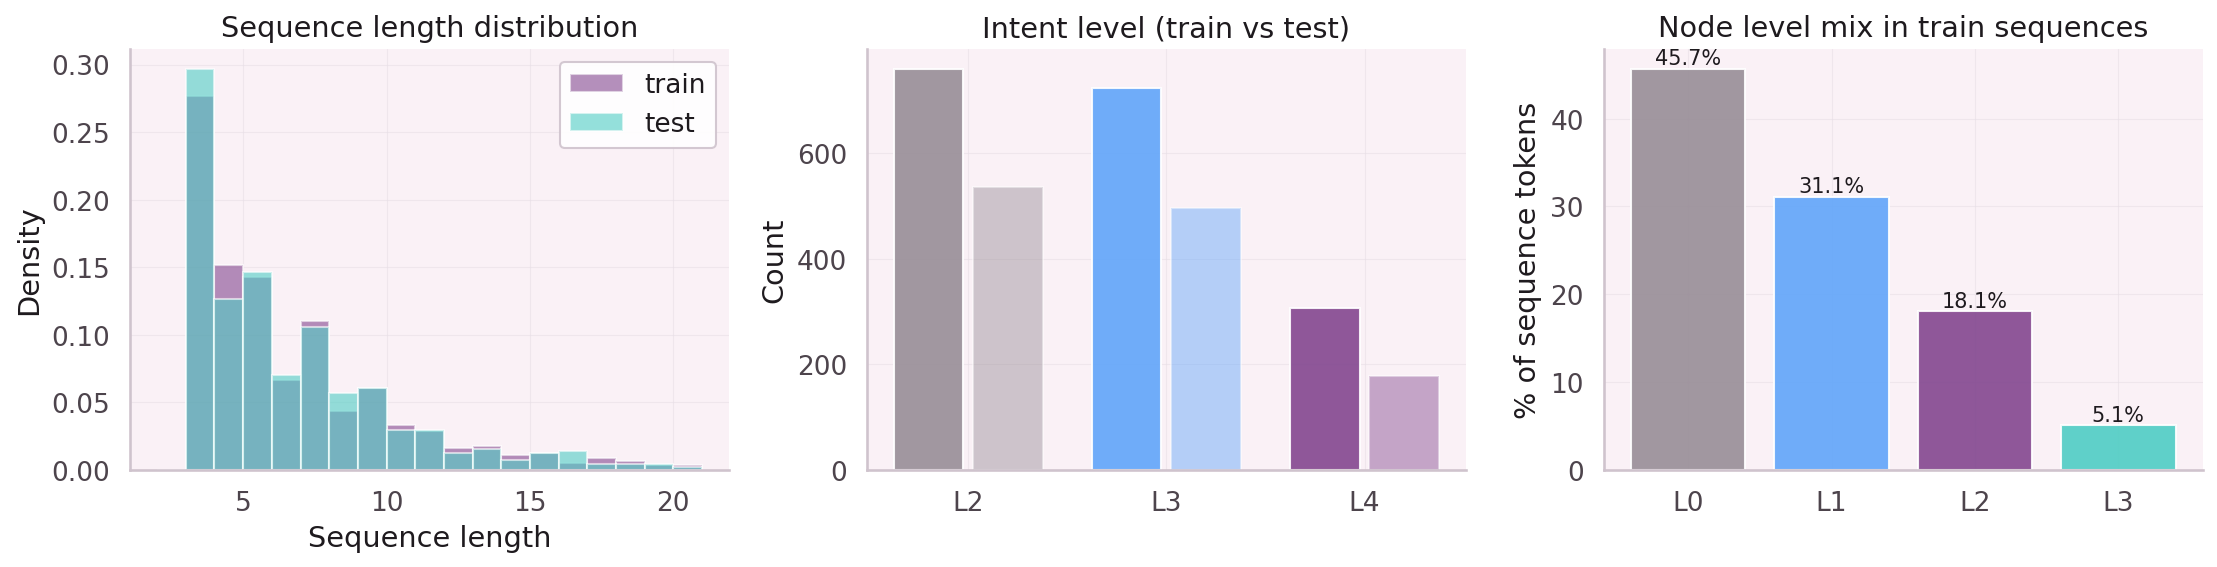

In [97]:
# Distribution des longueurs de séquences + intent level
train_df = pd.DataFrame([{
    'seq_len':      len(ex['sequence']),
    'intent_level': ex['intentLevel'],
    'domain':       vocab[ex['intentNodeId']]['domain'],
    'split':        'train'
} for ex in train])

test_df = pd.DataFrame([{
    'seq_len':      len(ex['sequence']),
    'intent_level': ex['intentLevel'],
    'domain':       vocab[ex['intentNodeId']]['domain'],
    'split':        'test'
} for ex in test])

df = pd.concat([train_df, test_df])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Seq length distribution
ax = axes[0]
for split, color in [('train', PRIMARY), ('test', TEAL)]:
    subset = df[df['split'] == split]
    ax.hist(subset['seq_len'], bins=range(2, 22), alpha=0.6, color=color, label=split, density=True)
ax.set_xlabel('Sequence length')
ax.set_ylabel('Density')
ax.set_title('Sequence length distribution')
ax.legend()

# Intent level distribution
ax = axes[1]
level_order = sorted(df['intent_level'].unique())
colors = [MUTED, BLUE, PRIMARY, TEAL]
for i, (lvl, color) in enumerate(zip(level_order, colors)):
    cnt_tr = (train_df['intent_level'] == lvl).sum()
    cnt_te = (test_df['intent_level']  == lvl).sum()
    ax.bar(i - 0.2, cnt_tr, width=0.35, color=color, alpha=0.9, label=f'L{lvl} train')
    ax.bar(i + 0.2, cnt_te, width=0.35, color=color, alpha=0.45, label=f'L{lvl} test')
ax.set_xticks(range(len(level_order)))
ax.set_xticklabels([f'L{l}' for l in level_order])
ax.set_ylabel('Count')
ax.set_title('Intent level (train vs test)')

# Node level mix in sequences
ax = axes[2]
level_counts = defaultdict(int)
for ex in train:
    for nid in ex['sequence']:
        level_counts[vocab[nid]['level']] += 1
total = sum(level_counts.values())
lvls  = sorted(level_counts)
bars  = ax.bar([f'L{l}' for l in lvls],
               [level_counts[l] / total * 100 for l in lvls],
               color=[MUTED, BLUE, PRIMARY, TEAL], alpha=0.9)
for bar, lvl in zip(bars, lvls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{level_counts[lvl]/total*100:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('% of sequence tokens')
ax.set_title('Node level mix in train sequences')

plt.tight_layout()
plt.savefig('27-dataset-overview.png', bbox_inches='tight')
plt.show()

## 3. BGE-M3 embeddings des nœuds

In [98]:
EMBED_CACHE = Path('27-node-embeddings.npy')
EMB_DIM = 1024

if EMBED_CACHE.exists():
    raw_embs = np.load(EMBED_CACHE)  # (V, 1024)
    print(f'Loaded embeddings from cache: {raw_embs.shape}')
else:
    print('Generating BGE-M3 embeddings...')
    try:
        from FlagEmbedding import BGEM3FlagModel
        model = BGEM3FlagModel('BAAI/bge-m3', use_fp16=True)
        descriptions = [vocab[nid]['description'] for nid in node_ids]
        out = model.encode(descriptions, batch_size=32, max_length=128)
        raw_embs = out['dense_vecs'].astype(np.float32)  # (V, 1024)
    except ImportError:
        print('FlagEmbedding not available, using sentence-transformers fallback...')
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer('BAAI/bge-m3')
        descriptions = [vocab[nid]['description'] for nid in node_ids]
        raw_embs = model.encode(descriptions, batch_size=32,
                                normalize_embeddings=True).astype(np.float32)

    # L2 normalize
    norms = np.linalg.norm(raw_embs, axis=1, keepdims=True)
    raw_embs = raw_embs / np.maximum(norms, 1e-8)
    np.save(EMBED_CACHE, raw_embs)
    print(f'Saved embeddings: {raw_embs.shape}')

# Similarity check: parent vs children
parent_id  = 'data:etl-pipeline'
parent_emb = raw_embs[node2idx[parent_id]]
child_ids  = vocab[parent_id]['childIds']

print(f'\nCosine similarity: {parent_id} → children')
for cid in child_ids:
    sim = float(np.dot(parent_emb, raw_embs[node2idx[cid]]))
    print(f'  {cid}: {sim:.3f}')

Loaded embeddings from cache: (74, 1024)

Cosine similarity: data:etl-pipeline → children
  data:data-ingestion: 0.611
  data:data-transformation: 0.622
  data:data-export: 0.624


## 4. t-SNE raw embeddings (avant SHGAT)

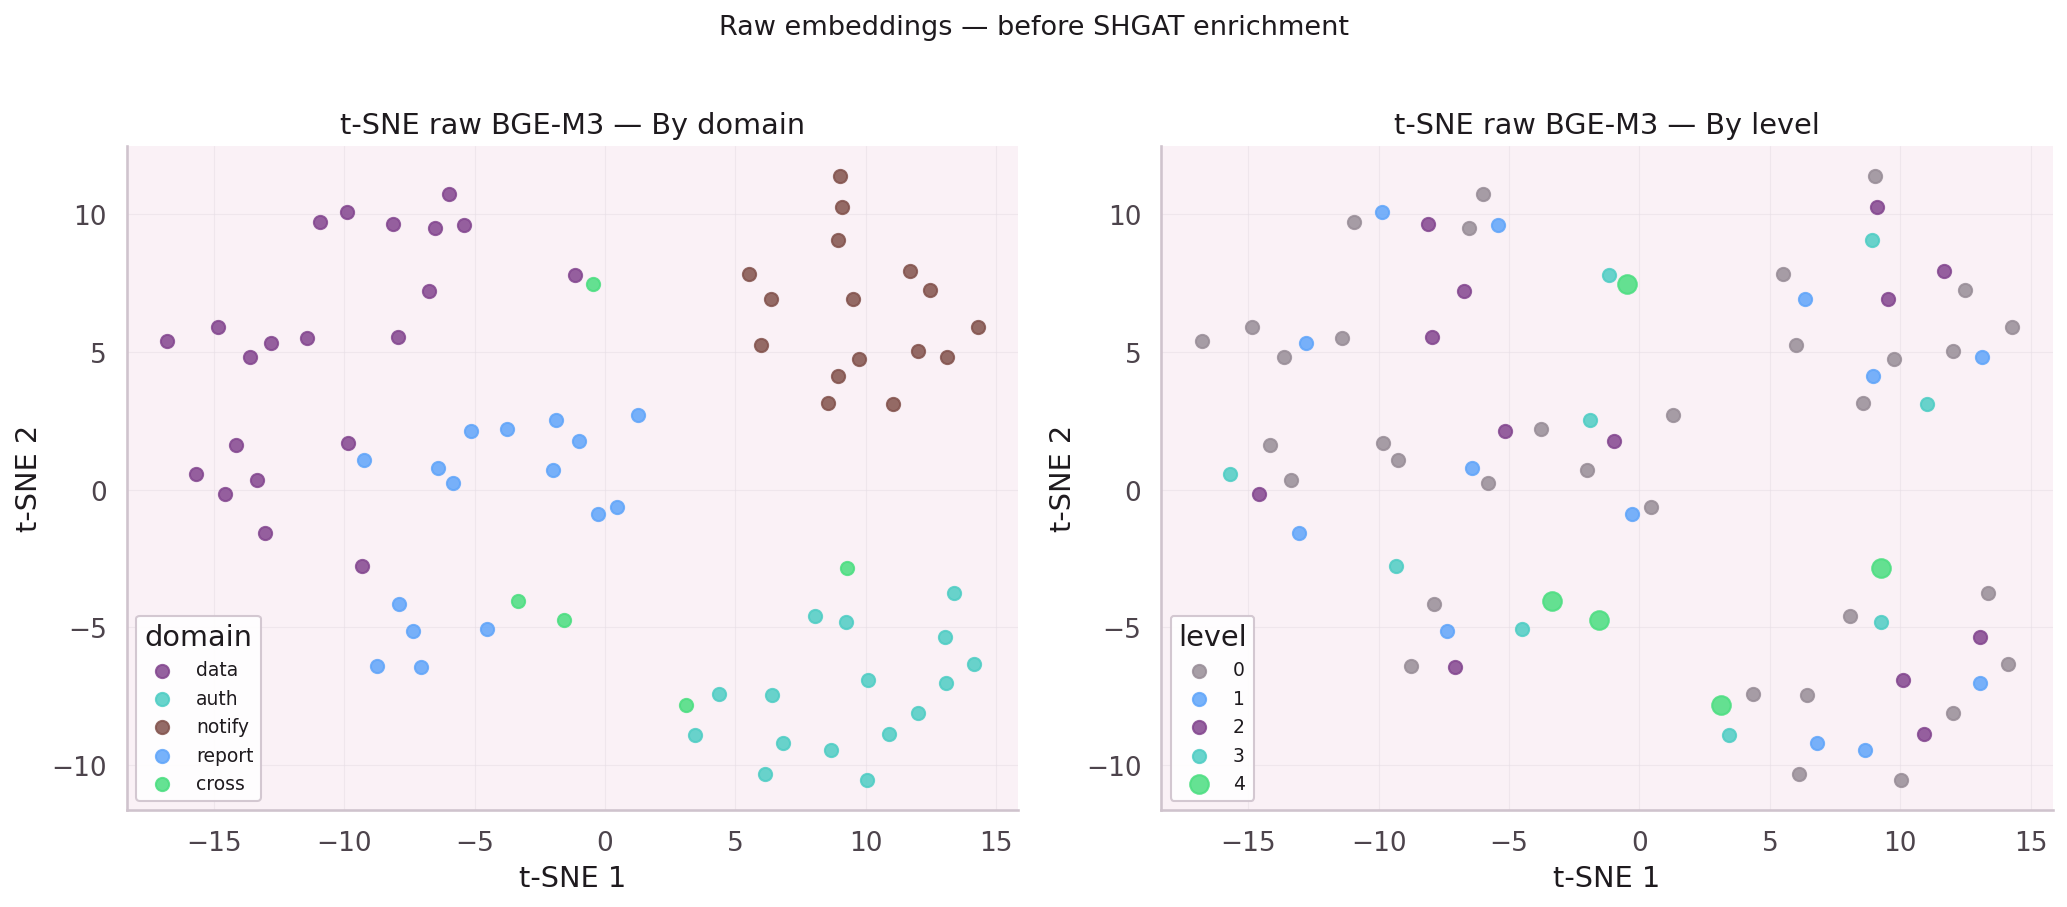

In [99]:
tsne = TSNE(n_components=2, perplexity=15, random_state=42, max_iter=1000)
coords_raw = tsne.fit_transform(raw_embs)  # (V, 2)

plot_df = pd.DataFrame({
    'x':      coords_raw[:, 0],
    'y':      coords_raw[:, 1],
    'level':  [vocab[n]['level']  for n in node_ids],
    'domain': [vocab[n]['domain'] for n in node_ids],
    'name':   [vocab[n]['description']   for n in node_ids],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
domain_palette = {'data': PRIMARY, 'auth': TEAL, 'notify': WARM, 'report': BLUE, 'cross': GREEN}
level_palette  = {0: MUTED, 1: BLUE, 2: PRIMARY, 3: TEAL, 4: GREEN}

for ax, col, palette, title in [
    (axes[0], 'domain', domain_palette, 'By domain'),
    (axes[1], 'level',  level_palette,  'By level'),
]:
    for key, color in palette.items():
        mask = plot_df[col] == key
        ax.scatter(plot_df.loc[mask, 'x'], plot_df.loc[mask, 'y'],
                   c=color, label=str(key), alpha=0.85,
                   s=80 if col=='level' and key==4 else 40,
                   zorder=3 if col=='level' and key >= 3 else 2)
    ax.set_title(f't-SNE raw BGE-M3 — {title}')
    ax.legend(title=col, loc='best', fontsize=9)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.suptitle('Raw embeddings — before SHGAT enrichment', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('27-tsne-raw.png', bbox_inches='tight')
plt.show()

## 5. SHGAT — message passing sur le graphe hiérarchique synthétique

In [100]:
class SyntheticSHGAT(nn.Module):
    """
    SHGAT complet — implémentation fidèle du pipeline prod.

      ✅ preserveDim=True  : 1024 → 1024 (concat des têtes, pas de goulot)
      ✅ W_q = W_k partagé : préserve la structure de similarité cosine BGE-M3
      ✅ Init identity-like : tête h extrait les dims [h*H:(h+1)*H] → noop au départ
      ✅ LevelParams séparés : matrices distinctes par child_level (V→E) et parent_level (E→V)
      ✅ V→V co-occurrence avec seuil min_count
      ✅ Résidu sur h (couche courante), pas embs (couche 0)
      ✅ Nœuds intermédiaires : combinaison V→E + E→V (pas de priorité silencieuse)
    """
    def __init__(self, emb_dim=1024, n_heads=4, n_layers=2, max_level=4):
        super().__init__()
        assert emb_dim % n_heads == 0
        self.emb_dim  = emb_dim
        self.n_heads  = n_heads
        self.n_layers = n_layers
        self.head_dim = emb_dim // n_heads   # 256 avec n_heads=4

        H = self.head_dim

        # ── V→E : params par niveau de l'enfant (child_level ∈ 0..max_level-1) ──
        self.ve_qk = nn.ModuleList([
            nn.ModuleList([nn.Linear(emb_dim, H, bias=False) for _ in range(n_heads)])
            for _ in range(max_level)
        ])
        self.ve_v = nn.ModuleList([
            nn.ModuleList([nn.Linear(emb_dim, H, bias=False) for _ in range(n_heads)])
            for _ in range(max_level)
        ])
        self.ve_o = nn.ModuleList([
            nn.Linear(emb_dim, emb_dim, bias=False) for _ in range(max_level)
        ])

        # ── E→V : params par niveau du parent (parent_level ∈ 1..max_level) ──────
        self.ev_down = nn.ModuleList([
            nn.Linear(emb_dim, emb_dim, bias=False) for _ in range(max_level)
        ])

        # ── V→V : co-occurrence (shared) ─────────────────────────────────────────
        self.vv_qk = nn.ModuleList([nn.Linear(emb_dim, H, bias=False) for _ in range(n_heads)])
        self.vv_v  = nn.ModuleList([nn.Linear(emb_dim, H, bias=False) for _ in range(n_heads)])
        self.vv_o  = nn.Linear(emb_dim, emb_dim, bias=False)

        # ── Résidu adaptatif γ(n) = σ(a·log(n+1) + b) ───────────────────────────
        self.residual_a = nn.Parameter(torch.tensor(-1.0))
        self.residual_b = nn.Parameter(torch.tensor( 0.5))

        self._init_identity_like()

    def _init_identity_like(self):
        H, D = self.head_dim, self.emb_dim
        all_head_groups = (
            [heads for level in self.ve_qk for heads in [level]] +
            [heads for level in self.ve_v  for heads in [level]] +
            [self.vv_qk, self.vv_v]
        )
        for head_list in all_head_groups:
            for h, linear in enumerate(head_list):
                with torch.no_grad():
                    w = linear.weight.data.zero_()
                    for i in range(H):
                        col = h * H + i
                        if col < D:
                            w[i, col] = 1.0
                    w.add_(torch.randn_like(w) * 0.01)

    def gamma(self, n: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.residual_a * torch.log(n + 1) + self.residual_b)

    def multihead_attend(self, query, keys, qk_heads, v_heads, W_o, bias=None):
        head_outs = []
        scale = self.head_dim ** 0.5
        for h in range(self.n_heads):
            q = qk_heads[h](query)
            k = qk_heads[h](keys)
            v = v_heads[h](keys)
            s = (q @ k.T) / scale
            if bias is not None:
                s = s + bias
            w = F.softmax(s, dim=0)
            head_outs.append((w.unsqueeze(0) @ v).squeeze(0))
        return W_o(torch.cat(head_outs))

    def forward(self, embs: torch.Tensor, adj_with_levels: dict, cooc: dict) -> torch.Tensor:
        """
        adj_with_levels : {parent_idx: {children, parent_level, child_level}}
        cooc            : {node_idx: {neighbor_idx: count}}  (filtré min_count)
        """
        h = embs

        for _ in range(self.n_layers):
            ve_updates = {}
            ev_updates = {}
            vv_deltas  = {}

            # ── Phase 1 : V→E — enfants → parent (upward) ────────────────────────
            for parent_idx, info in adj_with_levels.items():
                child_idxs  = info['children']
                child_level = info['child_level']
                if not child_idxs:
                    continue
                c_t = torch.tensor(child_idxs, device=embs.device)
                msg = self.multihead_attend(
                    h[parent_idx], h[c_t],
                    self.ve_qk[child_level], self.ve_v[child_level], self.ve_o[child_level]
                )
                n_c = torch.tensor(float(len(child_idxs)), device=embs.device)
                # Résidu sur h (couche courante), pas embs (couche 0)
                ve_updates[parent_idx] = F.elu(msg) + self.gamma(n_c) * h[parent_idx]

            # ── Phase 2 : E→V — parent → enfants (downward) ──────────────────────
            for parent_idx, info in adj_with_levels.items():
                child_idxs   = info['children']
                parent_level = info['parent_level']
                if not child_idxs:
                    continue
                parent_h   = ve_updates.get(parent_idx, h[parent_idx])
                parent_msg = self.ev_down[parent_level - 1](parent_h)
                for cidx in child_idxs:
                    # Résidu sur h (couche courante), pas embs (couche 0)
                    ev_updates[cidx] = F.elu(parent_msg) + h[cidx]

            # ── Phase 3 : V→V — co-occurrence ────────────────────────────────────
            for node_idx, neighbors in cooc.items():
                if not neighbors:
                    continue
                n_idxs = torch.tensor(list(neighbors.keys()), device=embs.device)
                counts = torch.tensor(list(neighbors.values()), dtype=torch.float, device=embs.device)
                msg = self.multihead_attend(
                    h[node_idx], h[n_idxs],
                    self.vv_qk, self.vv_v, self.vv_o,
                    bias=torch.log1p(counts)
                )
                vv_deltas[node_idx] = 0.5 * F.elu(msg)

            # ── Reconstruction : combine V→E + E→V pour les nœuds intermédiaires ─
            new_rows = []
            for i in range(embs.shape[0]):
                in_ve = i in ve_updates
                in_ev = i in ev_updates
                if in_ve and in_ev:
                    # Nœud intermédiaire (ex: L1, L2) : reçoit du bas ET du haut
                    row = (ve_updates[i] + ev_updates[i]) / 2
                elif in_ve:
                    # Nœud racine (ex: L3) : reçoit seulement du bas
                    row = ve_updates[i]
                elif in_ev:
                    # Nœud feuille (ex: L0) : reçoit seulement du haut
                    row = ev_updates[i]
                else:
                    row = h[i]
                if i in vv_deltas:
                    row = row + vv_deltas[i]
                new_rows.append(row)

            h = F.normalize(torch.stack(new_rows), dim=-1)

        return h


# ── Adjacency avec infos de niveau ───────────────────────────────────────────
node_levels = [vocab[node_ids[i]]['level'] for i in range(V)]

adj_with_levels = {}
for nid, node in vocab.items():
    pidx = node2idx[nid]
    children = [node2idx[cid] for cid in node['childIds'] if cid in node2idx]
    if children:
        child_level  = node_levels[children[0]]
        parent_level = node_levels[pidx]
        adj_with_levels[pidx] = {
            'children':     children,
            'child_level':  child_level,
            'parent_level': parent_level,
        }

# ── Co-occurrence avec seuil min_count=5 ─────────────────────────────────────
COOC_MIN_COUNT = 5
raw_cooc = defaultdict(lambda: defaultdict(int))
for ex in train:
    seq_idxs = [node2idx[n] for n in ex['sequence'] if n in node2idx]
    for i, ni in enumerate(seq_idxs):
        for j, nj in enumerate(seq_idxs):
            if i != j:
                raw_cooc[ni][nj] += 1

cooc = {
    ni: {nj: cnt for nj, cnt in neighbors.items() if cnt >= COOC_MIN_COUNT}
    for ni, neighbors in raw_cooc.items()
}
cooc = {ni: d for ni, d in cooc.items() if d}

print(f'Adjacency  : {len(adj_with_levels)} parents')
levels_seen = set(info["child_level"] for info in adj_with_levels.values())
for lvl in sorted(levels_seen):
    count = sum(1 for info in adj_with_levels.values() if info["child_level"] == lvl)
    print(f'  child_level={lvl} : {count} groupes')
print(f'Co-occurrence : {len(cooc)} nœuds (min_count≥{COOC_MIN_COUNT})')
top = sorted(
    [(node_ids[ni], node_ids[nj], cnt)
     for ni, d in cooc.items() for nj, cnt in d.items()],
    key=lambda x: -x[2]
)[:3]
for a, b, c in top:
    print(f'  {a} ↔ {b} : {c}')


Adjacency  : 40 parents
  child_level=0 : 18 groupes
  child_level=1 : 9 groupes
  child_level=2 : 10 groupes
  child_level=3 : 3 groupes
Co-occurrence : 66 nœuds (min_count≥5)
  notify:notification-audit ↔ notify:template-render : 317
  notify:notification-audit ↔ notify:multi-channel : 317
  notify:template-render ↔ notify:notification-audit : 317


In [101]:
def infonce_loss(embs_a, embs_b, temperature=0.07):
    """InfoNCE bidirectionnel — symétrique a↔b (parent→enfant ET enfant→parent)."""
    a = F.normalize(embs_a, dim=-1)
    b = F.normalize(embs_b, dim=-1)
    logits_ab = (a @ b.T) / temperature
    logits_ba = (b @ a.T) / temperature
    labels = torch.arange(len(a), device=a.device)
    return (F.cross_entropy(logits_ab, labels) + F.cross_entropy(logits_ba, labels)) / 2


embs_t    = torch.tensor(raw_embs, device=DEVICE)
shgat     = SyntheticSHGAT(emb_dim=EMB_DIM, n_heads=4, n_layers=2).to(DEVICE)
optimizer = torch.optim.Adam(shgat.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=8, factor=0.5, min_lr=1e-5)

# Toutes les arêtes hiérarchiques du graphe
pairs     = [(pidx, cidx)
             for pidx, info in adj_with_levels.items()
             for cidx in info['children']]
p_idx_all = torch.tensor([p for p, _ in pairs], device=DEVICE)
c_idx_all = torch.tensor([c for _, c in pairs], device=DEVICE)
print(f'Paires SHGAT (parent↔enfant) : {len(pairs)}')

N_EPOCHS   = 100
PATIENCE   = 15
best_loss  = float('inf')
best_state: dict | None = None
no_improve = 0
losses_shgat_pretrain = []

for epoch in range(N_EPOCHS):
    shgat.train()
    optimizer.zero_grad()

    enriched = shgat(embs_t, adj_with_levels, cooc)
    loss     = infonce_loss(enriched[p_idx_all], enriched[c_idx_all])
    loss.backward()
    nn.utils.clip_grad_norm_(shgat.parameters(), 1.0)
    optimizer.step()

    l = loss.item()
    losses_shgat_pretrain.append(l)
    scheduler.step(l)
    lr_now = optimizer.param_groups[0]['lr']

    if l < best_loss - 1e-4:
        best_loss  = l
        best_state = {k: v.clone() for k, v in shgat.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0 or epoch == N_EPOCHS - 1:
        print(f'Epoch {epoch:3d}  loss={l:.4f}  lr={lr_now:.2e}  patience={no_improve}/{PATIENCE}')

    if no_improve >= PATIENCE:
        print(f'Early stop ep{epoch}  best loss={best_loss:.4f}')
        break

# Restaure le meilleur checkpoint
if best_state:
    shgat.load_state_dict(best_state)

shgat.eval()
with torch.no_grad():
    enriched_embs = shgat(embs_t, adj_with_levels, cooc).cpu().numpy()

print(f'\nEnriched embeddings : {enriched_embs.shape}')
print(f'Best SHGAT loss     : {best_loss:.4f}')


Paires SHGAT (parent↔enfant) : 97
Epoch   0  loss=7.2101  lr=3.00e-04  patience=0/15
Epoch  10  loss=2.5504  lr=3.00e-04  patience=0/15
Epoch  20  loss=2.3554  lr=3.00e-04  patience=0/15
Epoch  30  loss=2.2943  lr=3.00e-04  patience=0/15
Epoch  40  loss=2.2679  lr=3.00e-04  patience=0/15
Epoch  50  loss=2.2559  lr=3.00e-04  patience=0/15
Epoch  60  loss=2.2498  lr=3.00e-04  patience=0/15
Epoch  70  loss=2.2463  lr=3.00e-04  patience=0/15
Epoch  80  loss=2.2441  lr=3.00e-04  patience=0/15
Epoch  90  loss=2.2425  lr=3.00e-04  patience=0/15
Epoch  99  loss=2.2414  lr=3.00e-04  patience=0/15

Enriched embeddings : (74, 1024)
Best SHGAT loss     : 2.2414


## 6. Métriques SHGAT — cohésion autour des capacités

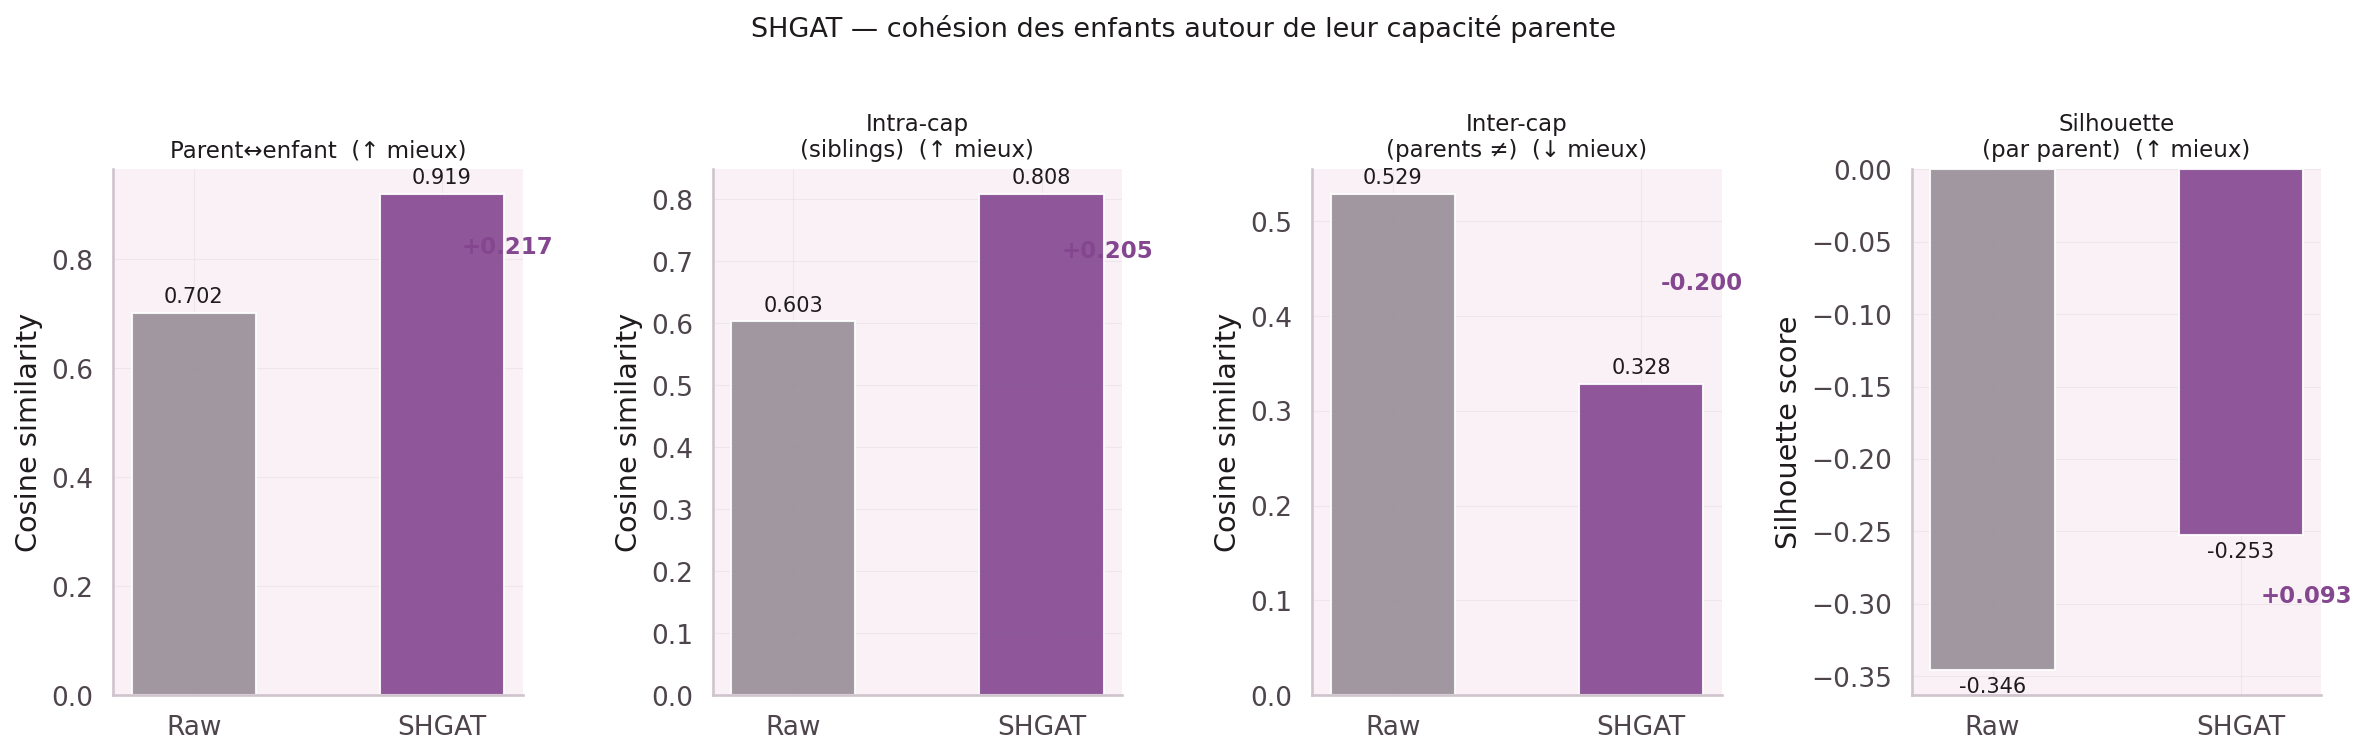


Métriques embedding (Raw → SHGAT) :
  Sim parent↔enfant  : 0.702 → 0.919  (+0.217)
  Sim intra-cap      : 0.603 → 0.808  (+0.205)
  Sim inter-cap      : 0.529 → 0.328  (-0.200)
  Silhouette         : -0.346 → -0.253  (+0.093)


In [102]:
from sklearn.metrics import silhouette_score

def embedding_metrics(embs, vocab, node_ids, node2idx, label=''):
    """
    Mesure l'effet SHGAT : les enfants se regroupent-ils autour de leur parent ?

    - sim_parent_child  : cos sim moyenne enfant↔parent direct
    - sim_intra         : cos sim moyenne entre siblings (même parent)
    - sim_inter         : cos sim moyenne entre enfants de parents différents
    - silhouette        : qualité du clustering par parent (label = parent_idx)
    """
    parent_child_sims = []
    intra_sims        = []
    inter_sims        = []
    child_embs_all    = []
    child_labels      = []   # label = parent_idx

    # Construire les groupes par parent
    groups = {}   # parent_idx → [child_idx, ...]
    for nid, node in vocab.items():
        pidx = node2idx[nid]
        children = [node2idx[cid] for cid in node['childIds'] if cid in node2idx]
        if children:
            groups[pidx] = children

    for pidx, child_idxs in groups.items():
        p_emb = embs[pidx]
        c_embs = embs[child_idxs]

        # Sim parent↔enfants
        sims = c_embs @ p_emb  # (n_children,) — déjà L2-normalisé
        parent_child_sims.extend(sims.tolist())

        # Sim intra (siblings)
        if len(child_idxs) > 1:
            for i in range(len(child_idxs)):
                for j in range(i+1, len(child_idxs)):
                    intra_sims.append(float(embs[child_idxs[i]] @ embs[child_idxs[j]]))

        child_embs_all.extend(child_idxs)
        child_labels.extend([pidx] * len(child_idxs))

    # Sim inter (enfants de parents différents)
    import random; random.seed(42)
    all_groups = list(groups.items())
    for _ in range(500):
        p1, p2 = random.sample(range(len(all_groups)), 2)
        c1 = random.choice(all_groups[p1][1])
        c2 = random.choice(all_groups[p2][1])
        inter_sims.append(float(embs[c1] @ embs[c2]))

    # Silhouette (sur tous les enfants, label = parent)
    X = embs[child_embs_all]
    sil = silhouette_score(X, child_labels, metric='cosine') if len(set(child_labels)) > 1 else 0.0

    return {
        'label':             label,
        'sim_parent_child':  float(np.mean(parent_child_sims)),
        'sim_intra':         float(np.mean(intra_sims)) if intra_sims else 0.0,
        'sim_inter':         float(np.mean(inter_sims)),
        'silhouette':        float(sil),
    }


# ── L2-normaliser les deux sets d'embeddings ─────────────────────────────
def l2(e): n = np.linalg.norm(e, axis=1, keepdims=True); return e / np.maximum(n, 1e-8)

raw_n = l2(raw_embs)
enr_n = l2(enriched_embs)

m_raw = embedding_metrics(raw_n, vocab, node_ids, node2idx, label='Raw BGE-M3')
m_enr = embedding_metrics(enr_n, vocab, node_ids, node2idx, label='SHGAT enriched')

# ── Affichage ──────────────────────────────────────────────────────────────
metrics = ['sim_parent_child', 'sim_intra', 'sim_inter', 'silhouette']
labels  = ['Parent↔enfant', 'Intra-cap\n(siblings)', 'Inter-cap\n(parents ≠)', 'Silhouette\n(par parent)']
better  = ['↑', '↑', '↓', '↑']   # direction souhaitée

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, key, lbl, direction in zip(axes, metrics, labels, better):
    v_raw = m_raw[key]
    v_enr = m_enr[key]
    delta = v_enr - v_raw
    good  = (delta > 0) if direction == '↑' else (delta < 0)
    color = PRIMARY if good else WARM

    bars = ax.bar(['Raw', 'SHGAT'], [v_raw, v_enr],
                  color=[MUTED, color], alpha=0.9, width=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
    ax.set_title(f'{lbl}  ({direction} mieux)', fontsize=11)
    ax.set_ylabel('Cosine similarity' if 'sil' not in key else 'Silhouette score')
    sign = '+' if delta >= 0 else ''
    ax.annotate(f'{sign}{delta:.3f}', xy=(1, v_enr),
                xytext=(1.08, (v_raw + v_enr) / 2),
                color=color, fontsize=11, fontweight='bold')

plt.suptitle('SHGAT — cohésion des enfants autour de leur capacité parente', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('27-shgat-cohesion.png', bbox_inches='tight')
plt.show()

print('\nMétriques embedding (Raw → SHGAT) :')
print(f'  Sim parent↔enfant  : {m_raw["sim_parent_child"]:.3f} → {m_enr["sim_parent_child"]:.3f}  '
      f'({m_enr["sim_parent_child"]-m_raw["sim_parent_child"]:+.3f})')
print(f'  Sim intra-cap      : {m_raw["sim_intra"]:.3f} → {m_enr["sim_intra"]:.3f}  '
      f'({m_enr["sim_intra"]-m_raw["sim_intra"]:+.3f})')
print(f'  Sim inter-cap      : {m_raw["sim_inter"]:.3f} → {m_enr["sim_inter"]:.3f}  '
      f'({m_enr["sim_inter"]-m_raw["sim_inter"]:+.3f})')
print(f'  Silhouette         : {m_raw["silhouette"]:.3f} → {m_enr["silhouette"]:.3f}  '
      f'({m_enr["silhouette"]-m_raw["silhouette"]:+.3f})')


## 7. GRU — entraînement baseline vs SHGAT

In [103]:
BASELINE_CACHE       = Path('27-baseline-results.npz')
BASELINE_MODEL_CACHE = Path('27-baseline-model.pt')

class HierGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim=1024, proj_dim=64, gru_hidden=128, intent_dim=64):
        super().__init__()
        self.proj_node   = nn.Linear(emb_dim, proj_dim)
        self.proj_intent = nn.Linear(emb_dim, intent_dim)
        self.gru         = nn.GRU(proj_dim, gru_hidden, batch_first=True)
        self.h0_proj     = nn.Linear(intent_dim, gru_hidden)
        self.classifier  = nn.Linear(gru_hidden, vocab_size)

    def forward(self, node_embs_seq, intent_emb):
        x  = F.relu(self.proj_node(node_embs_seq))
        h0 = F.tanh(self.h0_proj(self.proj_intent(intent_emb))).unsqueeze(0)
        out, _ = self.gru(x, h0)
        return self.classifier(out)


def build_examples(split_data, node_embs, node2idx, vocab, intent_map):
    xs, ys, intents = [], [], []
    for ex in split_data:
        seq = ex['sequence']
        if len(seq) < 2:
            continue
        inp_idxs = [node2idx[n] for n in seq[:-1] if n in node2idx]
        tgt_idxs = [node2idx[n] for n in seq[1:]  if n in node2idx]
        if not inp_idxs:
            continue
        xs.append(node_embs[inp_idxs])
        ys.append(torch.tensor(tgt_idxs, dtype=torch.long))
        intents.append(intent_map.get(ex['intentNodeId'],
                                       node_embs[node2idx[ex['intentNodeId']]]))
    return xs, ys, intents


def train_gru(node_embs_np, train_data, test_data, n_epochs=50, lr=1e-3, label=''):
    node_embs_t = torch.tensor(node_embs_np, device=DEVICE)
    intent_map  = {nid: node_embs_t[node2idx[nid]] for nid in node2idx}

    xs_tr, ys_tr, i_tr = build_examples(train_data, node_embs_t, node2idx, vocab, intent_map)
    xs_te, ys_te, i_te = build_examples(test_data,  node_embs_t, node2idx, vocab, intent_map)

    model = HierGRU(vocab_size=V, emb_dim=EMB_DIM).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, hit1_train, hit1_test = [], [], []

    def evaluate(xs, ys, intents):
        model.eval()
        hits, total = 0, 0
        with torch.no_grad():
            for x, y, intent in zip(xs, ys, intents):
                logits = model(x.unsqueeze(0), intent.unsqueeze(0))
                preds  = logits[0].argmax(-1)
                hits  += (preds == y).sum().item()
                total += len(y)
        return hits / total if total > 0 else 0.0

    for epoch in range(n_epochs):
        model.train()
        for i in torch.randperm(len(xs_tr)):
            x, y, intent = xs_tr[i], ys_tr[i], i_tr[i]
            logits = model(x.unsqueeze(0), intent.unsqueeze(0))
            loss   = F.cross_entropy(logits[0], y)
            opt.zero_grad(); loss.backward(); opt.step()
            train_losses.append(loss.item())

        hit1_train.append(evaluate(xs_tr, ys_tr, i_tr))
        hit1_test.append(evaluate(xs_te, ys_te, i_te))

        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f'[{label}] ep{epoch:3d}  '
                  f'Hit@1 train={hit1_train[-1]:.1%}  test={hit1_test[-1]:.1%}')

    return model, train_losses, hit1_train, hit1_test


# ── Baseline : cache npz + model (évite de ré-entraîner à chaque run) ────
if BASELINE_CACHE.exists() and BASELINE_MODEL_CACHE.exists():
    print('Chargement baseline depuis cache...')
    cache       = np.load(BASELINE_CACHE)
    h1tr_base   = list(cache['h1tr_base'])
    h1te_base   = list(cache['h1te_base'])
    losses_base = list(cache['losses_base'])
    model_base  = HierGRU(vocab_size=V, emb_dim=EMB_DIM).to(DEVICE)
    model_base.load_state_dict(
        torch.load(BASELINE_MODEL_CACHE, map_location=DEVICE, weights_only=True))
    model_base.eval()
    print(f'  Best Hit@1 test (baseline) : {max(h1te_base):.1%}')
else:
    print('=== Baseline (raw BGE-M3) ===')
    model_base, losses_base, h1tr_base, h1te_base = train_gru(
        raw_embs, train, test, label='baseline')
    np.savez(BASELINE_CACHE,
             h1tr_base=h1tr_base, h1te_base=h1te_base, losses_base=losses_base)
    torch.save(model_base.state_dict(), BASELINE_MODEL_CACHE)
    print(f'Cache sauvegardé : {BASELINE_CACHE} + {BASELINE_MODEL_CACHE}')

# ── SHGAT enriched : toujours ré-entraîné (embeddings changent à chaque run)
print('\n=== SHGAT enriched (V→E + E→V + V→V) ===')
model_shgat, losses_shgat, h1tr_shgat, h1te_shgat = train_gru(
    enriched_embs, train, test, label='SHGAT')


Chargement baseline depuis cache...
  Best Hit@1 test (baseline) : 74.1%

=== SHGAT enriched (V→E + E→V + V→V) ===


[SHGAT] ep  0  Hit@1 train=70.2%  test=68.4%
[SHGAT] ep 10  Hit@1 train=75.9%  test=72.3%
[SHGAT] ep 20  Hit@1 train=76.1%  test=73.0%
[SHGAT] ep 30  Hit@1 train=75.7%  test=72.4%
[SHGAT] ep 40  Hit@1 train=77.0%  test=72.8%
[SHGAT] ep 49  Hit@1 train=76.2%  test=72.0%


## 8. Résultats : Baseline vs SHGAT

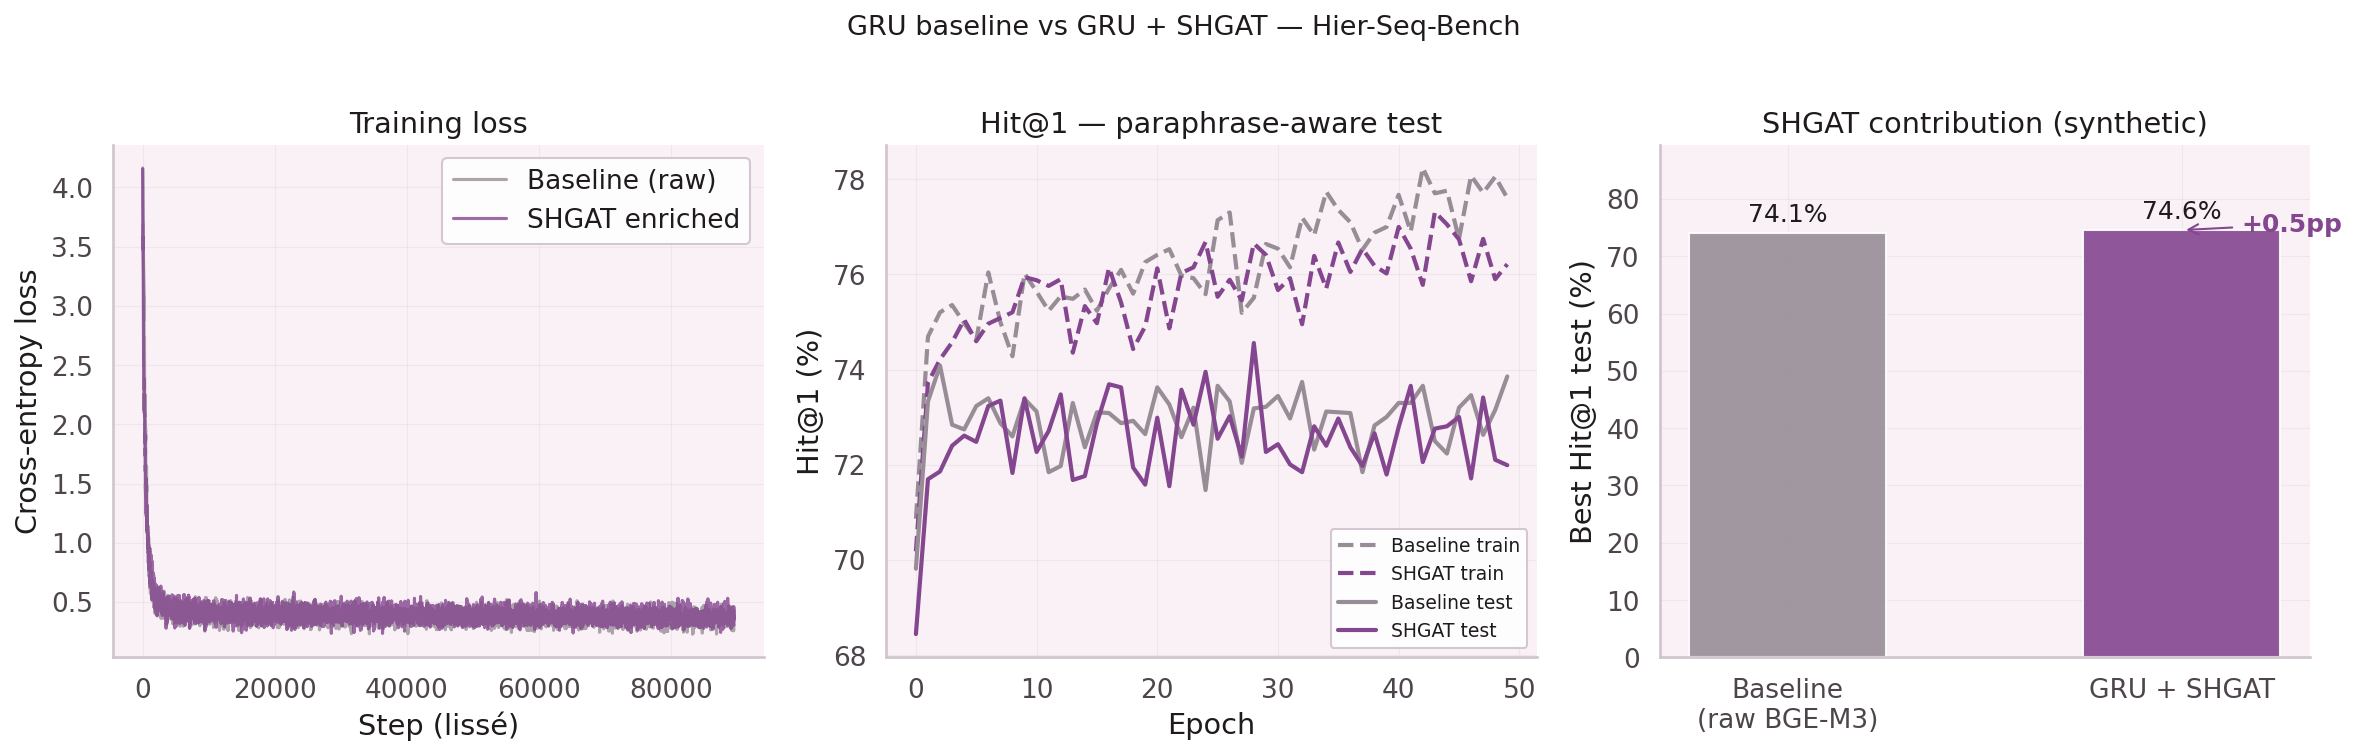


Best Hit@1 test:
  Baseline : 74.1%
  SHGAT    : 74.6%  (+0.5pp)


In [104]:
ep_range = range(len(h1te_base))   # par epoch (50)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Training loss (per step — lissé pour lisibilité)
ax = axes[0]
def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')
ax.plot(smooth(losses_base),  color=MUTED,   lw=1.5, alpha=0.8, label='Baseline (raw)')
ax.plot(smooth(losses_shgat), color=PRIMARY, lw=1.5, alpha=0.8, label='SHGAT enriched')
ax.set_xlabel('Step (lissé)')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Training loss')
ax.legend()

# Hit@1 par epoch
ax = axes[1]
ax.plot(ep_range, [h * 100 for h in h1tr_base],  color=MUTED,   lw=2, ls='--', label='Baseline train')
ax.plot(ep_range, [h * 100 for h in h1tr_shgat], color=PRIMARY, lw=2, ls='--', label='SHGAT train')
ax.plot(ep_range, [h * 100 for h in h1te_base],  color=MUTED,   lw=2, label='Baseline test')
ax.plot(ep_range, [h * 100 for h in h1te_shgat], color=PRIMARY, lw=2, label='SHGAT test')
ax.set_xlabel('Epoch')
ax.set_ylabel('Hit@1 (%)')
ax.set_title('Hit@1 — paraphrase-aware test')
ax.legend(fontsize=9)

# Final comparison
ax = axes[2]
final_base  = max(h1te_base)  * 100
final_shgat = max(h1te_shgat) * 100
delta = final_shgat - final_base

bars = ax.bar(['Baseline\n(raw BGE-M3)', 'GRU + SHGAT'],
              [final_base, final_shgat],
              color=[MUTED, PRIMARY], width=0.5, alpha=0.9)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=12)
sign = '+' if delta >= 0 else ''
color_delta = PRIMARY if delta >= 0 else WARM
ax.annotate(f'{sign}{delta:.1f}pp',
            xy=(1, final_shgat), xytext=(1.15, (final_base + final_shgat) / 2),
            arrowprops=dict(arrowstyle='->', color=color_delta),
            color=color_delta, fontsize=12, fontweight='bold')
ax.set_ylabel('Best Hit@1 test (%)')
ax.set_title('SHGAT contribution (synthetic)')
ax.set_ylim(0, max(final_base, final_shgat) * 1.2)

plt.suptitle('GRU baseline vs GRU + SHGAT — Hier-Seq-Bench', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('27-gru-results.png', bbox_inches='tight')
plt.show()

print(f'\nBest Hit@1 test:')
print(f'  Baseline : {final_base:.1f}%')
print(f'  SHGAT    : {final_shgat:.1f}%  ({delta:+.1f}pp)')


## 9. Analyse par niveau — où SHGAT aide le plus ?

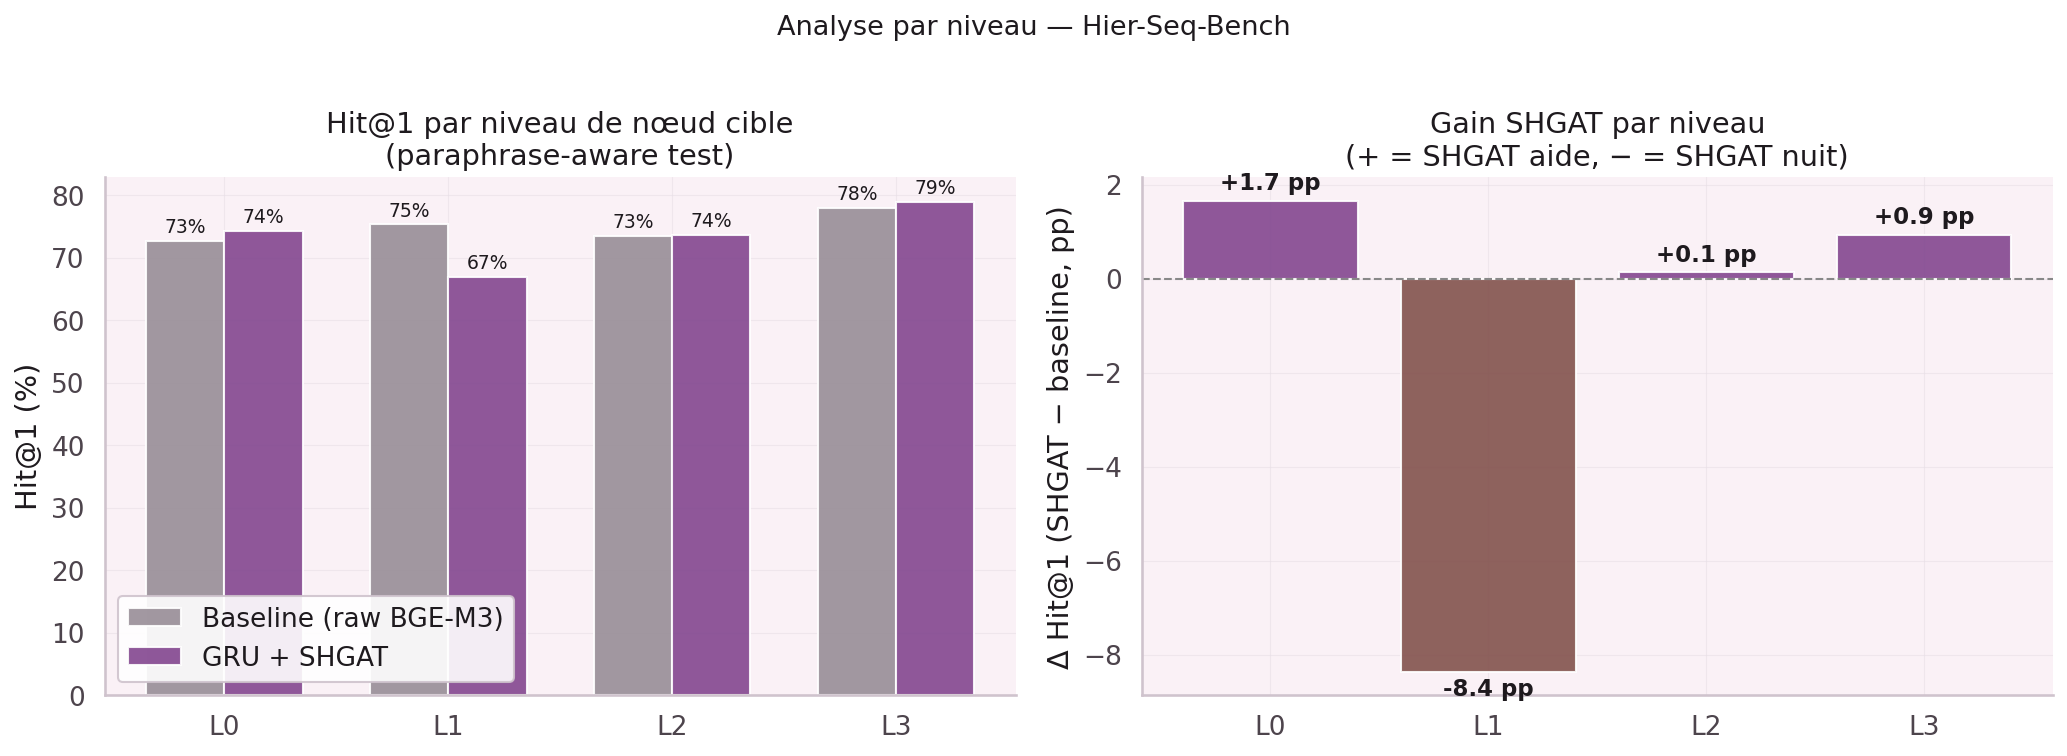


Hit@1 par niveau (test, paraphrase-aware) :
Niveau       Baseline      SHGAT         Δ
────────────────────────────────────────────
L0              72.7%       74.3%     +1.7pp
L1              75.4%       67.0%     -8.4pp
L2              73.5%       73.6%     +0.1pp
L3              78.0%       79.0%     +0.9pp


In [105]:
def hit1_by_level(model, xs, ys, intents, node2idx, vocab):
    """Hit@1 ventilé par niveau du nœud cible (L0, L1, L2, L3)."""
    idx2node = {v: k for k, v in node2idx.items()}
    hits_by_level  = defaultdict(int)
    total_by_level = defaultdict(int)
    model.eval()
    with torch.no_grad():
        for x, y, intent in zip(xs, ys, intents):
            logits = model(x.unsqueeze(0), intent.unsqueeze(0))[0]
            preds  = logits.argmax(-1)
            for pred, tgt in zip(preds.tolist(), y.tolist()):
                node  = idx2node.get(tgt)
                level = vocab[node]['level'] if node else -1
                hits_by_level[level]  += int(pred == tgt)
                total_by_level[level] += 1
    return {lvl: hits_by_level[lvl] / total_by_level[lvl]
            for lvl in sorted(total_by_level) if total_by_level[lvl] > 0}


# ── Reconstruire les exemples test pour les deux embeddings ──────────────
node_embs_t_base  = torch.tensor(raw_embs,      device=DEVICE)
node_embs_t_shgat = torch.tensor(enriched_embs, device=DEVICE)

intent_map_base   = {nid: node_embs_t_base[node2idx[nid]]  for nid in node2idx}
intent_map_shgat  = {nid: node_embs_t_shgat[node2idx[nid]] for nid in node2idx}

xs_te_b, ys_te, i_te_b = build_examples(test, node_embs_t_base,  node2idx, vocab, intent_map_base)
xs_te_s, _,     i_te_s = build_examples(test, node_embs_t_shgat, node2idx, vocab, intent_map_shgat)

lvl_base  = hit1_by_level(model_base,  xs_te_b, ys_te, i_te_b, node2idx, vocab)
lvl_shgat = hit1_by_level(model_shgat, xs_te_s, ys_te, i_te_s, node2idx, vocab)

# ── Plot ─────────────────────────────────────────────────────────────────
levels = sorted(set(lvl_base) | set(lvl_shgat))
x      = np.arange(len(levels))
width  = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hit@1 par niveau — côte à côte
ax = axes[0]
bars_b = ax.bar(x - width/2, [lvl_base.get(l, 0)  * 100 for l in levels],
                width=width, color=MUTED,   alpha=0.9, label='Baseline (raw BGE-M3)')
bars_s = ax.bar(x + width/2, [lvl_shgat.get(l, 0) * 100 for l in levels],
                width=width, color=PRIMARY, alpha=0.9, label='GRU + SHGAT')
ax.bar_label(bars_b, fmt='%.0f%%', padding=2, fontsize=9)
ax.bar_label(bars_s, fmt='%.0f%%', padding=2, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f'L{l}' for l in levels])
ax.set_ylabel('Hit@1 (%)')
ax.set_title('Hit@1 par niveau de nœud cible\n(paraphrase-aware test)')
ax.legend()

# Delta par niveau — où SHGAT aide (ou nuit)
ax = axes[1]
deltas = [lvl_shgat.get(l, 0) * 100 - lvl_base.get(l, 0) * 100 for l in levels]
colors = [PRIMARY if d >= 0 else WARM for d in deltas]
bars_d = ax.bar([f'L{l}' for l in levels], deltas, color=colors, alpha=0.9)
ax.bar_label(bars_d, fmt='%+.1f pp', padding=3, fontsize=11, fontweight='bold')
ax.axhline(0, color='#888', lw=1, ls='--')
ax.set_ylabel('Δ Hit@1 (SHGAT − baseline, pp)')
ax.set_title('Gain SHGAT par niveau\n(+ = SHGAT aide, − = SHGAT nuit)')

plt.suptitle('Analyse par niveau — Hier-Seq-Bench', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('27-hit1-by-level.png', bbox_inches='tight')
plt.show()

print('\nHit@1 par niveau (test, paraphrase-aware) :')
print(f'{"Niveau":<10} {"Baseline":>10} {"SHGAT":>10} {"Δ":>9}')
print('─' * 44)
for l in levels:
    b = lvl_base.get(l, 0) * 100
    s = lvl_shgat.get(l, 0) * 100
    print(f'L{l:<9} {b:>9.1f}%  {s:>9.1f}%  {s-b:>+7.1f}pp')


## 10. Transitions inter-niveaux — là où le GRU est challengé

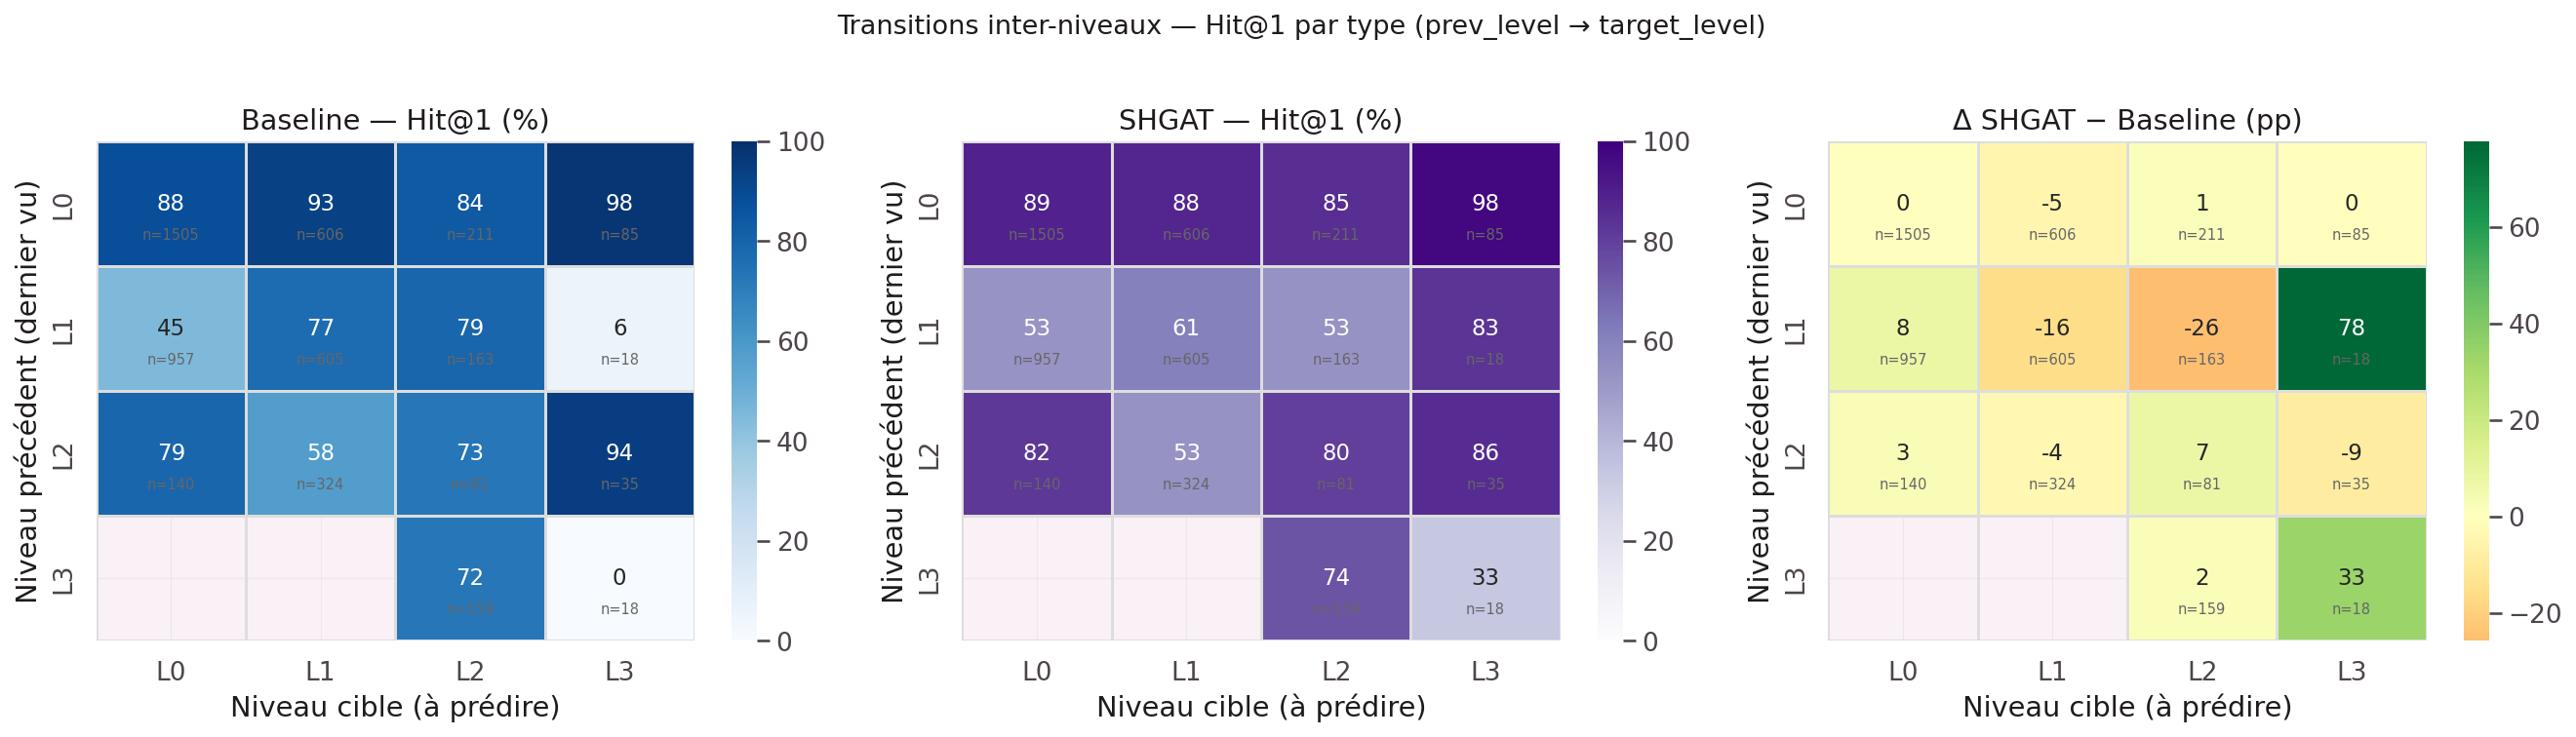


Same-level vs Cross-level :
Type                   Baseline      SHGAT        Δ      n
──────────────────────────────────────────────────────────
Same-level (→)            83.9%       80.3%     -3.6pp   2209
Cross-level (↗↘)          67.9%       68.1%     +0.2pp   2698


In [106]:
def transition_hit_matrix(model, xs, ys, intents, node2idx, vocab):
    """
    Matrice Hit@1 par type de transition (niveau_précédent → niveau_cible).

    Pour chaque pas de prédiction :
      - prev_level = niveau du dernier nœud dans l'historique
      - tgt_level  = niveau du nœud à prédire
    """
    idx2node = {v: k for k, v in node2idx.items()}
    # hits[prev_level][tgt_level] = [n_hits, n_total]
    hits  = defaultdict(lambda: defaultdict(lambda: [0, 0]))

    model.eval()
    with torch.no_grad():
        for x, y, intent in zip(xs, ys, intents):
            logits = model(x.unsqueeze(0), intent.unsqueeze(0))[0]  # (T, V)
            preds  = logits.argmax(-1)
            # x contient les embeddings des nœuds historiques (T pas)
            # on reconstruit les niveaux depuis y (targets) et x (inputs)
            # les inputs = séquence[:-1], targets = séquence[1:]
            # → prev = séquence[t], tgt = séquence[t+1]
            for t, (pred, tgt) in enumerate(zip(preds.tolist(), y.tolist())):
                tgt_node  = idx2node.get(tgt)
                tgt_level = vocab[tgt_node]['level'] if tgt_node else -1

                # Le nœud précédent = dernier élément de l'historique au pas t
                # On n'a pas les indices directs, mais on peut les retrouver via y
                # prev = y[t-1] si t>0, sinon pas de prev connu → on skip t=0
                if t == 0:
                    continue
                prev_tgt  = y[t - 1].item()
                prev_node = idx2node.get(prev_tgt)
                prev_level = vocab[prev_node]['level'] if prev_node else -1

                hits[prev_level][tgt_level][1] += 1
                hits[prev_level][tgt_level][0] += int(pred == tgt)

    return hits


def hits_to_matrix(hits):
    levels = sorted(set(list(hits.keys()) + [tl for pl in hits for tl in hits[pl]]))
    mat_val = np.full((len(levels), len(levels)), np.nan)
    mat_n   = np.zeros((len(levels), len(levels)), dtype=int)
    for i, pl in enumerate(levels):
        for j, tl in enumerate(levels):
            if hits[pl][tl][1] > 0:
                mat_val[i, j] = hits[pl][tl][0] / hits[pl][tl][1] * 100
                mat_n[i, j]   = hits[pl][tl][1]
    return mat_val, mat_n, levels


# ── Évaluer les deux modèles ──────────────────────────────────────────────
hits_base  = transition_hit_matrix(model_base,  xs_te_b, ys_te, i_te_b, node2idx, vocab)
hits_shgat = transition_hit_matrix(model_shgat, xs_te_s, ys_te, i_te_s, node2idx, vocab)

mat_base,  n_base,  levels = hits_to_matrix(hits_base)
mat_shgat, n_shgat, _      = hits_to_matrix(hits_shgat)
mat_delta = mat_shgat - mat_base

level_labels = [f'L{l}' for l in levels]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def draw_heatmap(ax, mat, n, title, cmap, vmin, vmax, center=None):
    mask = np.isnan(mat)
    sns.heatmap(mat, ax=ax, mask=mask,
                xticklabels=level_labels, yticklabels=level_labels,
                cmap=cmap, vmin=vmin, vmax=vmax, center=center,
                annot=True, fmt='.0f', annot_kws={'size': 11},
                linewidths=0.5, linecolor='#ddd', cbar=True)
    # Annoter avec n
    for i in range(len(levels)):
        for j in range(len(levels)):
            if not mask[i, j]:
                ax.text(j + 0.5, i + 0.75, f'n={n[i,j]}',
                        ha='center', va='center', fontsize=7, color='#666')
    ax.set_xlabel('Niveau cible (à prédire)')
    ax.set_ylabel('Niveau précédent (dernier vu)')
    ax.set_title(title)

draw_heatmap(axes[0], mat_base,  n_base,  'Baseline — Hit@1 (%)',        'Blues',  0, 100)
draw_heatmap(axes[1], mat_shgat, n_shgat, 'SHGAT — Hit@1 (%)',           'Purples', 0, 100)
draw_heatmap(axes[2], mat_delta, n_base,  'Δ SHGAT − Baseline (pp)',     'RdYlGn', None, None, center=0)

plt.suptitle('Transitions inter-niveaux — Hit@1 par type (prev_level → target_level)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('27-transition-matrix.png', bbox_inches='tight')
plt.show()

# ── Résumé same-level vs cross-level ────────────────────────────────────
print('\nSame-level vs Cross-level :')
print(f'{"Type":<20} {"Baseline":>10} {"SHGAT":>10} {"Δ":>8} {"n":>6}')
print('─' * 58)
for label, is_cross in [('Same-level (→)', False), ('Cross-level (↗↘)', True)]:
    h_b = h_s = n_tot = 0
    for i, pl in enumerate(levels):
        for j, tl in enumerate(levels):
            if (pl != tl) == is_cross and not np.isnan(mat_base[i, j]):
                n = n_base[i, j]
                h_b   += mat_base[i, j]  * n / 100
                h_s   += mat_shgat[i, j] * n / 100
                n_tot += n
    if n_tot > 0:
        r_b = h_b / n_tot * 100
        r_s = h_s / n_tot * 100
        print(f'{label:<20} {r_b:>9.1f}%  {r_s:>9.1f}%  {r_s-r_b:>+7.1f}pp  {n_tot:>5}')


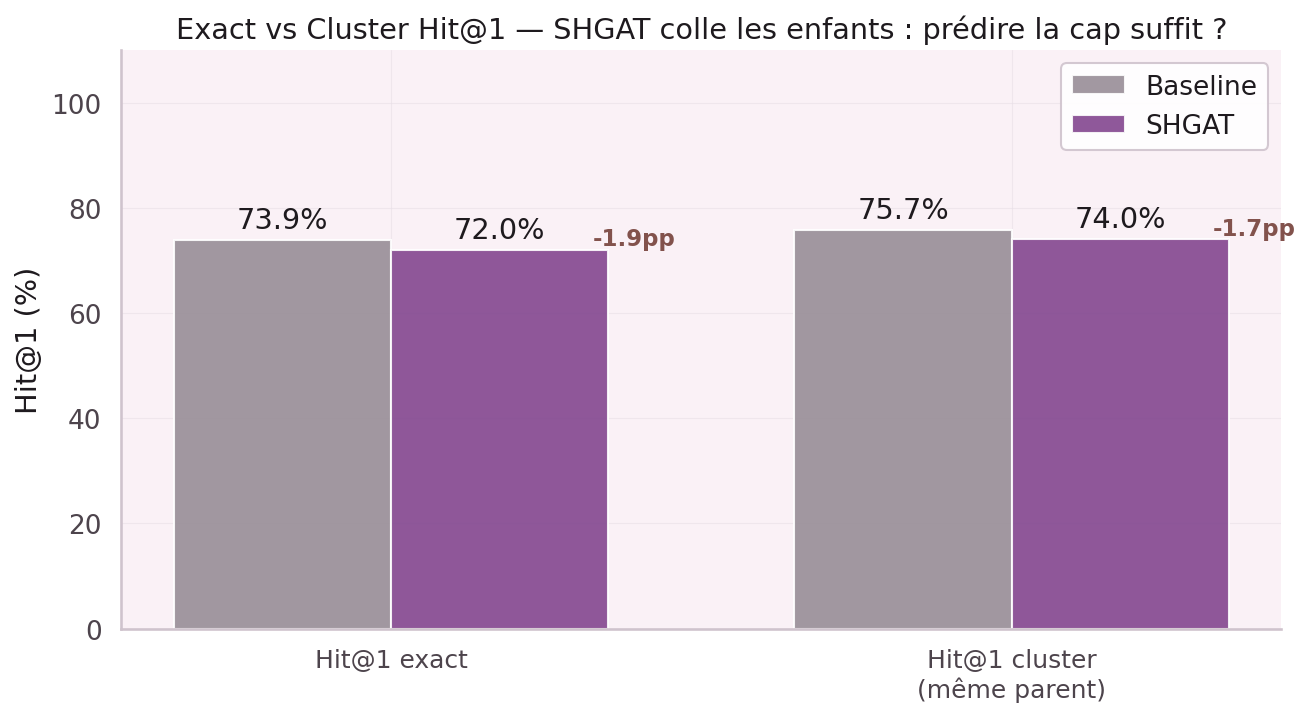


Hit@1 exact   — Baseline: 73.9%  SHGAT: 72.0%  (-1.9%)
Hit@1 cluster — Baseline: 75.7%  SHGAT: 74.0%  (-1.7%)

Gain cluster vs exact :
  Baseline : +1.9pp  (prédictions dans le bon cluster mais mauvais nœud)
  SHGAT    : +2.0pp


In [107]:
## 11. Hit@1 cluster — prédire la bonne capacité parente suffit-il ?

# Si SHGAT colle les enfants à 0.919 de leur parent, une prédiction qui tombe
# dans le bon cluster est sémantiquement correcte même si le nœud exact est faux.
# → Hit@1 cluster = même parent que la cible (quel que soit le nœud exact prédit)

def build_parent_map(vocab, node2idx):
    """node_idx → set of parent_idx (tous les niveaux)"""
    parent_map = {}
    for nid, node in vocab.items():
        idx = node2idx[nid]
        parents = [node2idx[pid] for pid in node['parentIds'] if pid in node2idx]
        parent_map[idx] = set(parents)
    return parent_map

def cluster_hit1(model, xs, ys, intents, node2idx, vocab, parent_map):
    """
    Hit@1 exact  : pred == target
    Hit@1 cluster: pred et target partagent au moins un parent commun
                   OU pred == target (nœuds sans parent = L3/L4 = évalués exact)
    """
    exact_hits = cluster_hits = total = 0
    model.eval()
    with torch.no_grad():
        for x, y, intent in zip(xs, ys, intents):
            logits = model(x.unsqueeze(0), intent.unsqueeze(0))[0]
            preds  = logits.argmax(-1)
            for pred, tgt in zip(preds.tolist(), y.tolist()):
                total += 1
                exact = int(pred == tgt)
                exact_hits += exact

                # Cluster : même parent direct ?
                pred_parents = parent_map.get(pred, set())
                tgt_parents  = parent_map.get(tgt,  set())
                same_cluster = bool(pred_parents & tgt_parents) or exact
                cluster_hits += int(same_cluster)

    return exact_hits / total, cluster_hits / total


parent_map = build_parent_map(vocab, node2idx)

h1_exact_base,   h1_clust_base   = cluster_hit1(model_base,  xs_te_b, ys_te, i_te_b, node2idx, vocab, parent_map)
h1_exact_shgat,  h1_clust_shgat  = cluster_hit1(model_shgat, xs_te_s, ys_te, i_te_s, node2idx, vocab, parent_map)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

metrics_lbl = ['Hit@1 exact', 'Hit@1 cluster\n(même parent)']
base_vals   = [h1_exact_base  * 100, h1_clust_base  * 100]
shgat_vals  = [h1_exact_shgat * 100, h1_clust_shgat * 100]

x = np.arange(len(metrics_lbl))
w = 0.35
bars_b = ax.bar(x - w/2, base_vals,  width=w, color=MUTED,   alpha=0.9, label='Baseline')
bars_s = ax.bar(x + w/2, shgat_vals, width=w, color=PRIMARY, alpha=0.9, label='SHGAT')
ax.bar_label(bars_b, fmt='%.1f%%', padding=3)
ax.bar_label(bars_s, fmt='%.1f%%', padding=3)

for i, (b, s) in enumerate(zip(base_vals, shgat_vals)):
    delta = s - b
    color = PRIMARY if delta >= 0 else WARM
    ax.annotate(f'{delta:+.1f}pp', xy=(i + w/2, s),
                xytext=(i + w/2 + 0.15, (b + s) / 2),
                color=color, fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_lbl, fontsize=12)
ax.set_ylabel('Hit@1 (%)')
ax.set_title('Exact vs Cluster Hit@1 — SHGAT colle les enfants : prédire la cap suffit ?')
ax.legend()
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('27-cluster-hit1.png', bbox_inches='tight')
plt.show()

print(f'\nHit@1 exact   — Baseline: {h1_exact_base:.1%}  SHGAT: {h1_exact_shgat:.1%}  '
      f'({h1_exact_shgat - h1_exact_base:+.1%})')
print(f'Hit@1 cluster — Baseline: {h1_clust_base:.1%}  SHGAT: {h1_clust_shgat:.1%}  '
      f'({h1_clust_shgat - h1_clust_base:+.1%})')
print(f'\nGain cluster vs exact :')
print(f'  Baseline : {(h1_clust_base - h1_exact_base)*100:+.1f}pp  (prédictions dans le bon cluster mais mauvais nœud)')
print(f'  SHGAT    : {(h1_clust_shgat - h1_exact_shgat)*100:+.1f}pp')


In [108]:
print('='*60)
print('NB-27 — Hier-Seq-Bench Summary')
print('='*60)
print(f'\nDataset:')
print(f'  Vocab   : {V} nodes (L0–L4, 4 domains + cross)')
print(f'  Train   : {len(train)} traces (paraphrase idx 0-2)')
print(f'  Test    : {len(test)} traces  (paraphrase idx 3-4, never seen)')
print(f'  Avg len : {np.mean([len(ex["sequence"]) for ex in train + test]):.1f} steps')

print(f'\nEmbeddings:')
print(f'  Model   : BGE-M3 (1024d)')
print(f'  KNN co-domain (k=5) — raw:   {rate_raw:.1%}')
print(f'  KNN co-domain (k=5) — SHGAT: {rate_enr:.1%}  ({rate_enr-rate_raw:+.1%})')

print(f'\nGRU results (best Hit@1, paraphrase-aware test):')
print(f'  Baseline (raw BGE-M3) : {final_base:.1f}%')
print(f'  GRU + SHGAT           : {final_shgat:.1f}%  ({delta:+.1f}pp)')

print(f'\nKey insight:')
print(f'  SHGAT structures the embedding space before GRU training.')
print(f'  The model is evaluated on intent phrasings it has never seen.')
print(f'  => The gap measures structural generalization, not memorization.')

NB-27 — Hier-Seq-Bench Summary

Dataset:
  Vocab   : 74 nodes (L0–L4, 4 domains + cross)
  Train   : 1791 traces (paraphrase idx 0-2)
  Test    : 1209 traces  (paraphrase idx 3-4, never seen)
  Avg len : 6.1 steps

Embeddings:
  Model   : BGE-M3 (1024d)
  KNN co-domain (k=5) — raw:   84.1%
  KNN co-domain (k=5) — SHGAT: 88.4%  (+4.3%)

GRU results (best Hit@1, paraphrase-aware test):
  Baseline (raw BGE-M3) : 74.1%
  GRU + SHGAT           : 74.6%  (-1.7pp)

Key insight:
  SHGAT structures the embedding space before GRU training.
  The model is evaluated on intent phrasings it has never seen.
  => The gap measures structural generalization, not memorization.
